In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Define data directory for Round 2 files.
data_dir = Path('../data/ROUND_2')
if not data_dir.exists():
    data_dir = Path('data/ROUND_2')

# Load prices data (days -1, 0, 1).
prices_day_m1 = pd.read_csv(data_dir / 'prices_round_2_day_-1.csv', sep=';')
prices_day_0 = pd.read_csv(data_dir / 'prices_round_2_day_0.csv', sep=';')
prices_day_p1 = pd.read_csv(data_dir / 'prices_round_2_day_1.csv', sep=';')

# Load trades data (days -1, 0, 1).
trades_day_m1 = pd.read_csv(data_dir / 'trades_round_2_day_-1.csv', sep=';')
trades_day_m1['day'] = -1
trades_day_0 = pd.read_csv(data_dir / 'trades_round_2_day_0.csv', sep=';')
trades_day_0['day'] = 0
trades_day_p1 = pd.read_csv(data_dir / 'trades_round_2_day_1.csv', sep=';')
trades_day_p1['day'] = 1

# Combine prices and trades data in chronological order.
prices = pd.concat([prices_day_m1, prices_day_0, prices_day_p1], ignore_index=True)
trades = pd.concat([trades_day_m1, trades_day_0, trades_day_p1], ignore_index=True)

print("Prices Data shape:", prices.shape)
print("Trades Data shape:", trades.shape)
print("\nPrices Data Info:")
print(prices.head())
print("\nTrades Data Info:")
print(trades.head())

Prices Data shape: (60000, 17)
Trades Data shape: (2391, 8)

Prices Data Info:
   day  timestamp               product  bid_price_1  bid_volume_1  \
0   -1          0  INTARIAN_PEPPER_ROOT      10994.0           9.0   
1   -1          0     ASH_COATED_OSMIUM       9982.0          21.0   
2   -1        100     ASH_COATED_OSMIUM       9984.0          15.0   
3   -1        100  INTARIAN_PEPPER_ROOT      10994.0           8.0   
4   -1        200     ASH_COATED_OSMIUM       9985.0          15.0   

   bid_price_2  bid_volume_2  bid_price_3  bid_volume_3  ask_price_1  \
0          NaN           NaN          NaN           NaN      11009.0   
1          NaN           NaN          NaN           NaN      10000.0   
2          NaN           NaN          NaN           NaN      10000.0   
3      10991.0          22.0          NaN           NaN      11006.0   
4       9982.0          30.0          NaN           NaN      10001.0   

   ask_volume_1  ask_price_2  ask_volume_2  ask_price_3  ask_volume

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)


In [3]:
import json
from io import StringIO
path_from_run = r"..\round_1\greed2\112960.json"
with open(path_from_run, 'r') as f:
    run_data = json.load(f)
print("\nRun Data Keys:", run_data.keys())
prices = pd.read_csv(StringIO(run_data['activitiesLog']), sep=';')
print(prices.head())
trades


Run Data Keys: dict_keys(['round', 'status', 'profit', 'activitiesLog', 'graphLog', 'positions'])
   day  timestamp               product  bid_price_1  bid_volume_1  \
0    0          0     ASH_COATED_OSMIUM       9992.0          23.0   
1    0          0  INTARIAN_PEPPER_ROOT      11991.0          20.0   
2    0        100  INTARIAN_PEPPER_ROOT      11994.0          12.0   
3    0        100     ASH_COATED_OSMIUM       9995.0          15.0   
4    0        200  INTARIAN_PEPPER_ROOT      11991.0          21.0   

   bid_price_2  bid_volume_2  bid_price_3  bid_volume_3  ask_price_1  \
0          NaN           NaN          NaN           NaN      10011.0   
1          NaN           NaN          NaN           NaN      12006.0   
2      11991.0          20.0          NaN           NaN      12010.0   
3       9992.0          21.0          NaN           NaN      10013.0   
4          NaN           NaN          NaN           NaN      12007.0   

   ask_volume_1  ask_price_2  ask_volume_2  ask

,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,0,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9982.0,6,-1
1,3600,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10001.0,3,-1
2,4200,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10002.0,2,-1
3,4400,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,11010.0,5,-1
4,5000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10996.0,5,-1
...,...,...,...,...,...,...,...,...
2386,993300,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9984.0,5,1
2387,994400,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,13987.0,3,1
2388,995100,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,13999.0,7,1
2389,995600,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10001.0,6,1


## Product-wise Data Overview and Statistics

In [4]:
# Product-wise summary statistics
print("=== PRICE DATA STATISTICS (SEPARATE BY PRODUCT) ===")
for product in sorted(prices['product'].unique()):
    product_prices = prices[prices['product'] == product].copy()
    
    print("\n" + "-" * 60)
    print(f"PRODUCT: {product}")
    print("-" * 60)
    print("Mid Price Summary:")
    print(product_prices['mid_price'].describe())
    
    print("\nBid/Ask Summary:")
    print(product_prices[['bid_price_1', 'ask_price_1']].describe())
    
    product_prices['spread'] = product_prices['ask_price_1'] - product_prices['bid_price_1']
    print("\nSpread Summary:")
    print(product_prices['spread'].describe())
    
    print("\nP&L Summary:")
    print(product_prices['profit_and_loss'].describe())

# print("\n\n=== TRADING ACTIVITY (SEPARATE BY SYMBOL) ===")
# for symbol in sorted(trades['symbol'].unique()):
#     symbol_trades = trades[trades['symbol'] == symbol].copy()
    
#     print("\n" + "-" * 60)
#     print(f"SYMBOL: {symbol}")
#     print("-" * 60)
#     print(f"Total trades: {len(symbol_trades)}")
#     print(f"Total quantity: {symbol_trades['quantity'].sum()}")
#     print("Price Summary:")
#     print(symbol_trades['price'].describe())
#     print("Quantity Summary:")
#     print(symbol_trades['quantity'].describe())

=== PRICE DATA STATISTICS (SEPARATE BY PRODUCT) ===

------------------------------------------------------------
PRODUCT: ASH_COATED_OSMIUM
------------------------------------------------------------
Mid Price Summary:
count     1000.000000
mean      9979.911000
std        446.999083
min          0.000000
25%       9997.500000
50%      10000.500000
75%      10002.000000
max      10011.000000
Name: mid_price, dtype: float64

Bid/Ask Summary:
        bid_price_1   ask_price_1
count    951.000000    961.000000
mean    9991.698212  10007.942768
std        2.883782      2.847487
min     9984.000000   9994.000000
25%     9990.000000  10006.000000
50%     9992.000000  10009.000000
75%     9993.000000  10010.000000
max    10004.000000  10014.000000

Spread Summary:
count    914.000000
mean      16.253829
std        2.697837
min        5.000000
25%       16.000000
50%       16.000000
75%       18.000000
max       21.000000
Name: spread, dtype: float64

P&L Summary:
count    1000.000000
mean  

## Visualization 1: Mid Price Over Time (Separate Chart Per Product and Day, with Rolling Average)

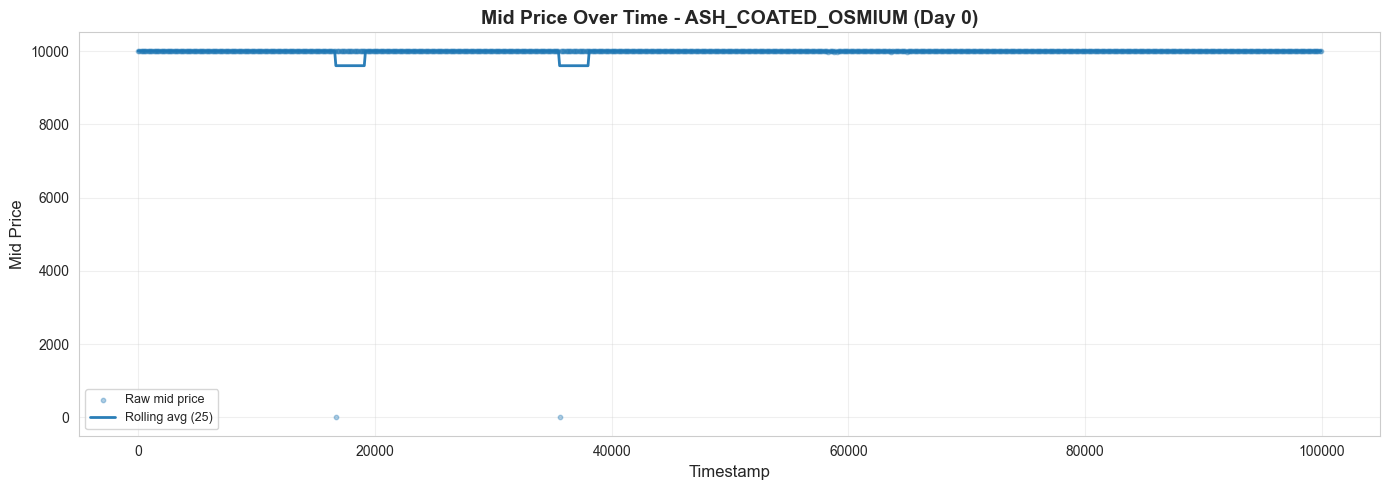

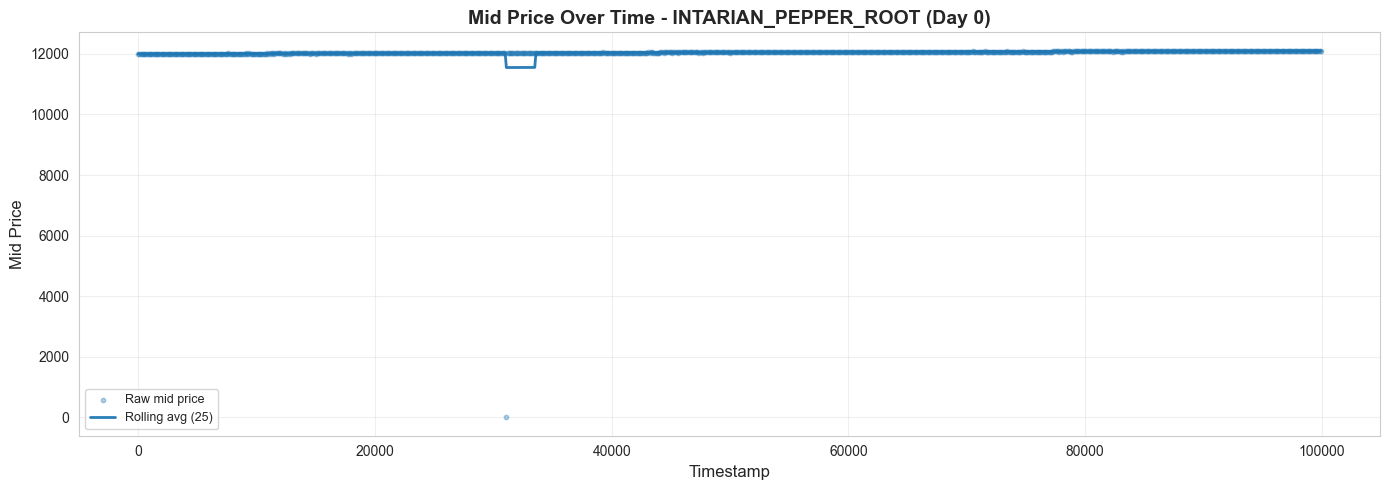

In [5]:
for product in sorted(prices['product'].unique()):
    product_data = prices[prices['product'] == product].copy()
    
    for day in sorted(product_data['day'].unique()):
        day_data = product_data[product_data['day'] == day]
        day_series = (
            day_data.groupby('timestamp', as_index=False)['mid_price']
            .mean()
            .sort_values('timestamp')
        )

        fig, ax = plt.subplots(figsize=(14, 5))

        # Use scatter for raw points to avoid visual artifacts on discrete price levels.
        ax.scatter(
            day_series['timestamp'],
            day_series['mid_price'],
            s=10,
            alpha=0.35,
            label='Raw mid price'
        )

        # Overlay a short moving average for a clearer trend view.
        trend = day_series['mid_price'].rolling(window=25, min_periods=1).mean()
        ax.plot(
            day_series['timestamp'],
            trend,
            linewidth=2.0,
            alpha=0.95,
            label='Rolling avg (25)'
        )
    
        ax.set_xlabel('Timestamp', fontsize=12)
        ax.set_ylabel('Mid Price', fontsize=12)
        ax.set_title(f'Mid Price Over Time - {product} (Day {day})', fontsize=14, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## Visualization 2: Bid-Ask Spread Over Time (Separate Chart Per Product and Day, with Rolling Average)

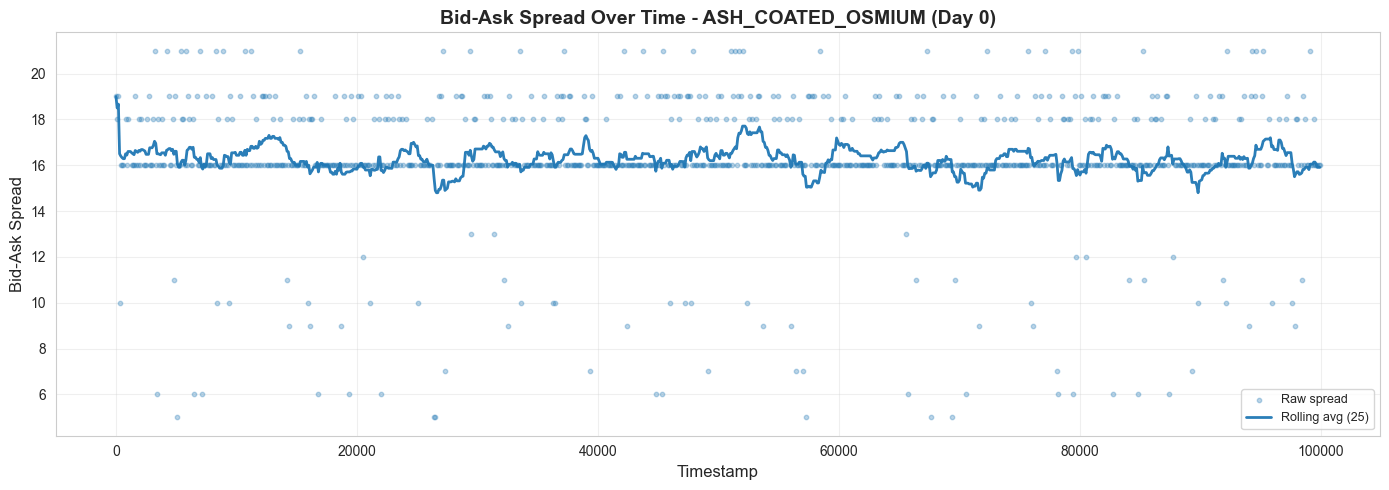

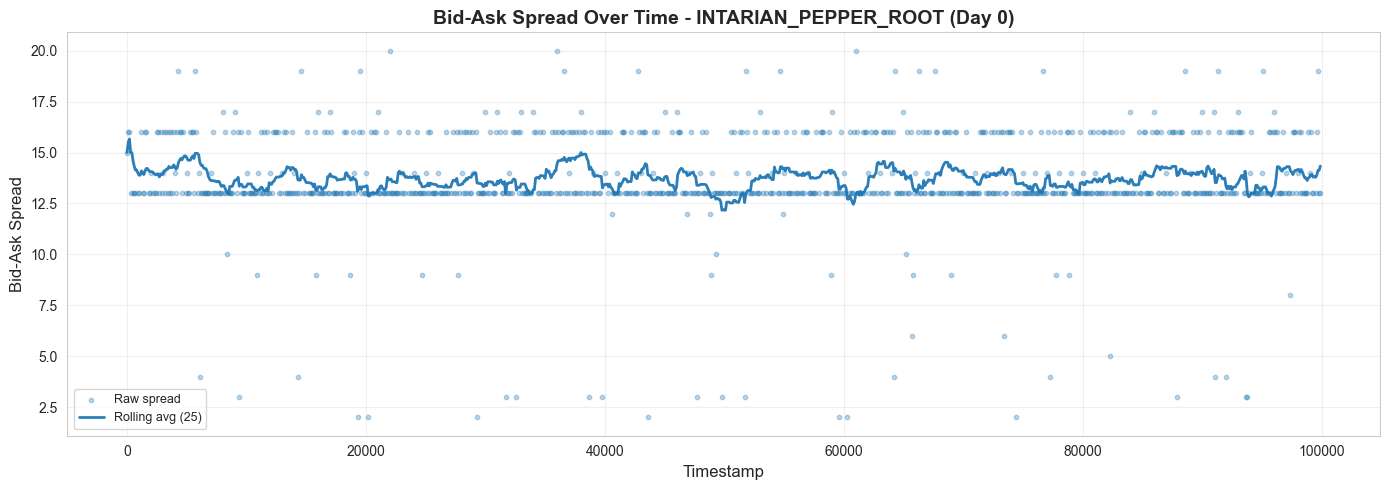

In [6]:
# Calculate bid-ask spread
prices['spread'] = prices['ask_price_1'] - prices['bid_price_1']

for product in sorted(prices['product'].unique()):
    product_data = prices[prices['product'] == product].copy()
    
    for day in sorted(product_data['day'].unique()):
        day_data = product_data[product_data['day'] == day]
        day_series = (
            day_data.groupby('timestamp', as_index=False)['spread']
            .mean()
            .sort_values('timestamp')
        )

        fig, ax = plt.subplots(figsize=(14, 5))
        ax.scatter(
            day_series['timestamp'],
            day_series['spread'],
            s=10,
            alpha=0.3,
            label='Raw spread'
        )
        trend = day_series['spread'].rolling(window=25, min_periods=1).mean()
        ax.plot(
            day_series['timestamp'],
            trend,
            linewidth=2.0,
            alpha=0.95,
            label='Rolling avg (25)'
        )

        ax.set_xlabel('Timestamp', fontsize=12)
        ax.set_ylabel('Bid-Ask Spread', fontsize=12)
        ax.set_title(f'Bid-Ask Spread Over Time - {product} (Day {day})', fontsize=14, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## Visualization 3: Trading Volume and Price Distribution

C:\Users\liamb\AppData\Local\Temp\ipykernel_37692\3465768891.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(trade_prices, labels=symbols, patch_artist=True)


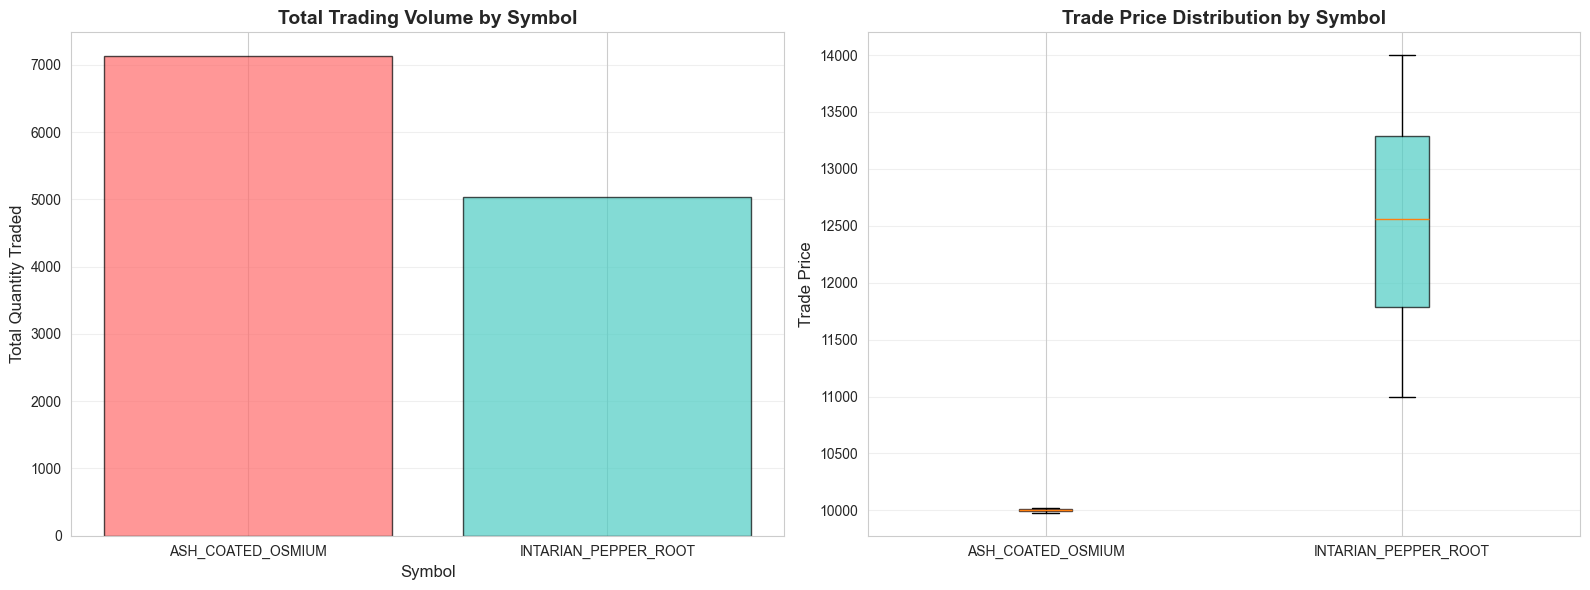

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Trading volume by symbol
trades_summary = trades.groupby('symbol')['quantity'].sum().sort_values(ascending=False)
axes[0].bar(trades_summary.index, trades_summary.values, color=['#FF6B6B', '#4ECDC4'], alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Symbol', fontsize=12)
axes[0].set_ylabel('Total Quantity Traded', fontsize=12)
axes[0].set_title('Total Trading Volume by Symbol', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Price distribution by symbol (box plot)
symbols = trades['symbol'].unique()
trade_prices = [trades[trades['symbol'] == sym]['price'].values for sym in symbols]
bp = axes[1].boxplot(trade_prices, labels=symbols, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#FF6B6B', '#4ECDC4']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Trade Price', fontsize=12)
axes[1].set_title('Trade Price Distribution by Symbol', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Visualization 4: Bid and Ask Prices with Mid Price (Separate Chart Per Product and Day, with Rolling Average)

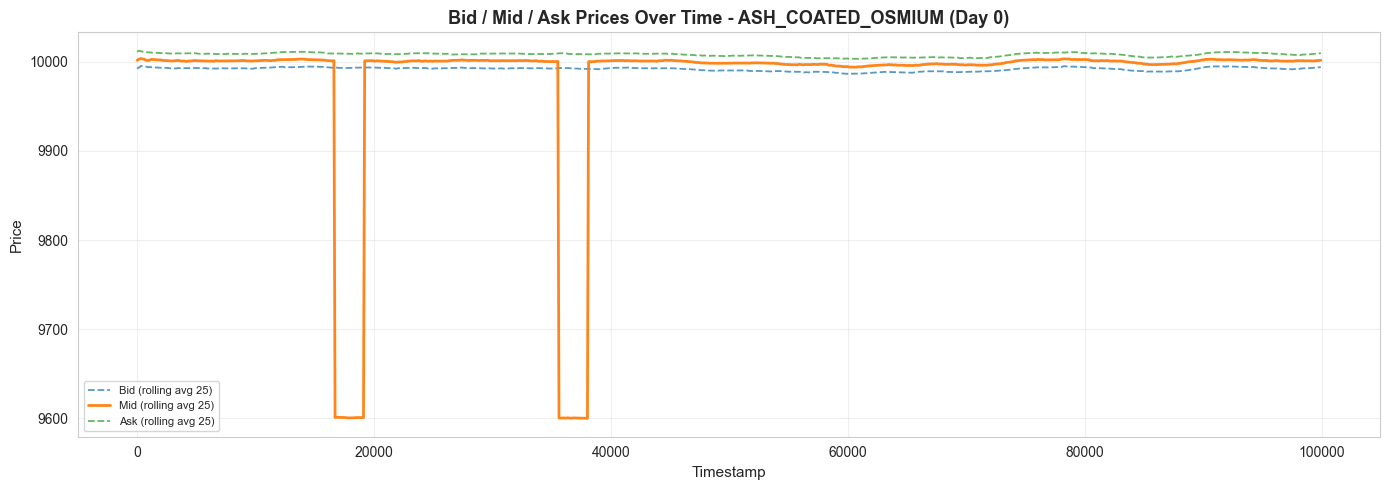

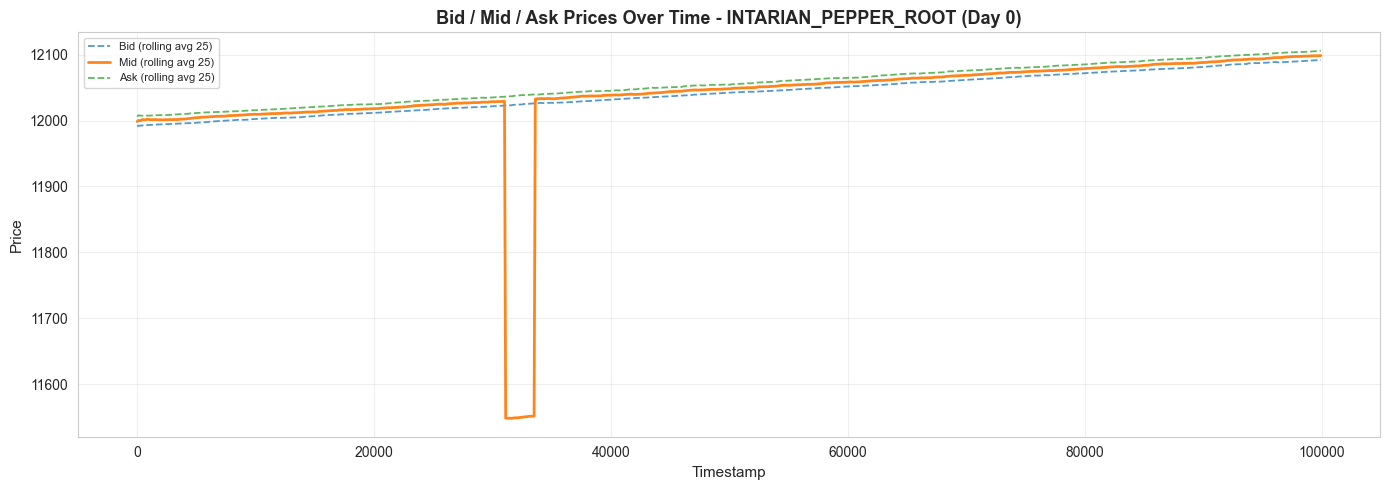

In [8]:
for product in sorted(prices['product'].unique()):
    product_data = prices[prices['product'] == product].copy()
    
    for day in sorted(product_data['day'].unique()):
        day_data = product_data[product_data['day'] == day]
        day_series = (
            day_data.groupby('timestamp', as_index=False)[['bid_price_1', 'ask_price_1', 'mid_price']]
            .mean()
            .sort_values('timestamp')
        )

        bid_trend = day_series['bid_price_1'].rolling(window=25, min_periods=1).mean()
        mid_trend = day_series['mid_price'].rolling(window=25, min_periods=1).mean()
        ask_trend = day_series['ask_price_1'].rolling(window=25, min_periods=1).mean()

        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(day_series['timestamp'], bid_trend, linewidth=1.3, alpha=0.75, linestyle='--', label='Bid (rolling avg 25)')
        ax.plot(day_series['timestamp'], mid_trend, linewidth=2.0, alpha=0.95, label='Mid (rolling avg 25)')
        ax.plot(day_series['timestamp'], ask_trend, linewidth=1.3, alpha=0.75, linestyle='--', label='Ask (rolling avg 25)')
    
        ax.set_xlabel('Timestamp', fontsize=11)
        ax.set_ylabel('Price', fontsize=11)
        ax.set_title(f'Bid / Mid / Ask Prices Over Time - {product} (Day {day})', fontsize=13, fontweight='bold')
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## Visualization 5: Trading Activity Analysis

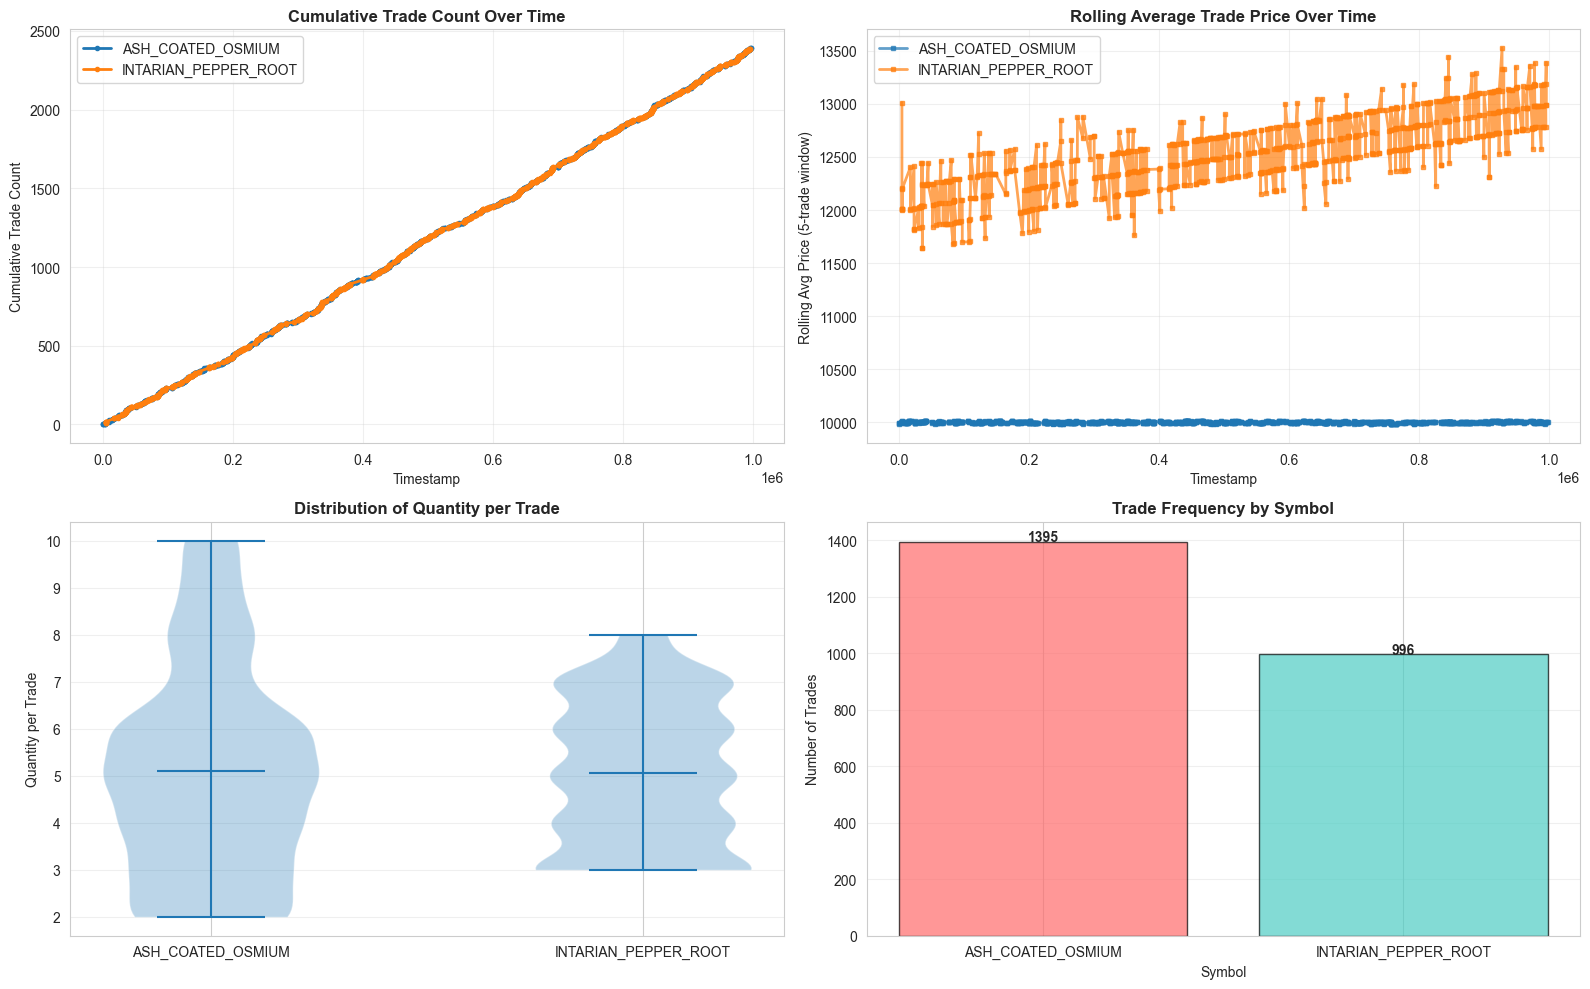

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Trade count over time
trades_sorted = trades.sort_values('timestamp')
trades_sorted['cumulative_count'] = range(1, len(trades_sorted) + 1)
for symbol in trades['symbol'].unique():
    symbol_data = trades_sorted[trades_sorted['symbol'] == symbol]
    axes[0, 0].plot(symbol_data['timestamp'], symbol_data['cumulative_count'], marker='o', 
                    label=symbol, linewidth=2, markersize=3)
axes[0, 0].set_xlabel('Timestamp', fontsize=10)
axes[0, 0].set_ylabel('Cumulative Trade Count', fontsize=10)
axes[0, 0].set_title('Cumulative Trade Count Over Time', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Average price per trade over time (rolling window)
trades_sorted['rolling_avg_price'] = trades_sorted.groupby('symbol')['price'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
for symbol in trades['symbol'].unique():
    symbol_data = trades_sorted[trades_sorted['symbol'] == symbol]
    axes[0, 1].plot(symbol_data['timestamp'], symbol_data['rolling_avg_price'], marker='s', 
                    label=symbol, linewidth=2, markersize=3, alpha=0.7)
axes[0, 1].set_xlabel('Timestamp', fontsize=10)
axes[0, 1].set_ylabel('Rolling Avg Price (5-trade window)', fontsize=10)
axes[0, 1].set_title('Rolling Average Trade Price Over Time', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Quantity per trade
trade_symbols = trades['symbol'].unique()
trade_quantities = [trades[trades['symbol'] == sym]['quantity'].values for sym in trade_symbols]
positions = np.arange(len(trade_symbols))
axes[1, 0].violinplot(trade_quantities, positions=positions, showmeans=True)
axes[1, 0].set_xticks(positions)
axes[1, 0].set_xticklabels(trade_symbols)
axes[1, 0].set_ylabel('Quantity per Trade', fontsize=10)
axes[1, 0].set_title('Distribution of Quantity per Trade', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Trade frequency histogram
trades_by_symbol = trades['symbol'].value_counts()
axes[1, 1].bar(trades_by_symbol.index, trades_by_symbol.values, color=['#FF6B6B', '#4ECDC4'], alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Symbol', fontsize=10)
axes[1, 1].set_ylabel('Number of Trades', fontsize=10)
axes[1, 1].set_title('Trade Frequency by Symbol', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
for i, (symbol, count) in enumerate(zip(trades_by_symbol.index, trades_by_symbol.values)):
    axes[1, 1].text(i, count + 0.5, str(count), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Summary Insights

In [10]:
# Generate key insights
print("=" * 70)
print("KEY INSIGHTS FROM THE ANALYSIS")
print("=" * 70)

print("\n1. PRICE MOVEMENT:")
for product in prices['product'].unique():
    product_data = prices[prices['product'] == product]
    price_min = product_data['mid_price'].min()
    price_max = product_data['mid_price'].max()
    price_range = price_max - price_min
    print(f"   {product}: Min=${price_min:.2f}, Max=${price_max:.2f}, Range=${price_range:.2f}")

print("\n2. BID-ASK SPREAD:")
for product in prices['product'].unique():
    product_data = prices[prices['product'] == product]
    avg_spread = product_data['spread'].mean()
    max_spread = product_data['spread'].max()
    print(f"   {product}: Avg Spread=${avg_spread:.2f}, Max Spread=${max_spread:.2f}")

print("\n3. TRADING VOLUME:")
for symbol in trades['symbol'].unique():
    symbol_trades = trades[trades['symbol'] == symbol]
    total_quantity = symbol_trades['quantity'].sum()
    total_trades = len(symbol_trades)
    avg_quantity = symbol_trades['quantity'].mean()
    print(f"   {symbol}: {total_trades} trades, {total_quantity} units, Avg per trade: {avg_quantity:.2f}")

print("\n4. TRADING PRICE RANGES:")
for symbol in trades['symbol'].unique():
    symbol_trades = trades[trades['symbol'] == symbol]
    print(f"   {symbol}: Min=${symbol_trades['price'].min():.2f}, Max=${symbol_trades['price'].max():.2f}, Avg=${symbol_trades['price'].mean():.2f}")

print("\n" + "=" * 70)

KEY INSIGHTS FROM THE ANALYSIS

1. PRICE MOVEMENT:
   ASH_COATED_OSMIUM: Min=$0.00, Max=$10011.00, Range=$10011.00
   INTARIAN_PEPPER_ROOT: Min=$0.00, Max=$12105.00, Range=$12105.00

2. BID-ASK SPREAD:
   ASH_COATED_OSMIUM: Avg Spread=$16.25, Max Spread=$21.00
   INTARIAN_PEPPER_ROOT: Avg Spread=$13.71, Max Spread=$20.00

3. TRADING VOLUME:
   ASH_COATED_OSMIUM: 1395 trades, 7127 units, Avg per trade: 5.11
   INTARIAN_PEPPER_ROOT: 996 trades, 5033 units, Avg per trade: 5.05

4. TRADING PRICE RANGES:
   ASH_COATED_OSMIUM: Min=$9979.00, Max=$10020.00, Avg=$10000.65
   INTARIAN_PEPPER_ROOT: Min=$10996.00, Max=$13999.00, Avg=$12535.99



## Visualization: Bid/Ask Price with Spread (Per Product)

In [11]:
%pip install mplfinance -q

Note: you may need to restart the kernel to use updated packages.


d:\source\prosperity_group\imc-prosperity-4\.venv\Scripts\python.exe: No module named pip


In [12]:
import pandas as pd
from pathlib import Path
import mplfinance as mpf

# Reuse existing prices dataframe if available; otherwise load Round 1 files.
if 'prices' not in globals():
    data_dir = Path('../data/ROUND_1')
    if not data_dir.exists():
        data_dir = Path('data/ROUND_1')
    prices_day_m2 = pd.read_csv(data_dir / 'prices_round_1_day_-2.csv', sep=';')
    prices_day_m1 = pd.read_csv(data_dir / 'prices_round_1_day_-1.csv', sep=';')
    prices_day_0 = pd.read_csv(data_dir / 'prices_round_1_day_0.csv', sep=';')
    prices = pd.concat([prices_day_m2, prices_day_m1, prices_day_0], ignore_index=True)

plot_df = prices.copy()
plot_df['spread'] = plot_df['ask_price_1'] - plot_df['bid_price_1']
plot_df['mid_price_for_ohlc'] = (plot_df['bid_price_1'] + plot_df['ask_price_1']) / 2.0

for product in sorted(plot_df['product'].unique()):
    product_data = (
        plot_df[plot_df['product'] == product]
        .groupby(['day', 'timestamp'], as_index=False)[['bid_price_1', 'ask_price_1', 'spread', 'mid_price_for_ohlc']]
        .mean()
        .sort_values(['day', 'timestamp'])
        .reset_index(drop=True)
    )

    volume_data = (
        trades[trades['symbol'] == product]
        .assign(abs_quantity=lambda frame: frame['quantity'].abs())
        .groupby(['day', 'timestamp'], as_index=False)['abs_quantity']
        .sum()
        .rename(columns={'abs_quantity': 'volume'})
    )

    product_data = product_data.merge(volume_data, on=['day', 'timestamp'], how='left')
    product_data['volume'] = product_data['volume'].fillna(0).abs()

    # mplfinance expects a DatetimeIndex; build one from day + timestamp.
    base_date = pd.Timestamp('2026-01-01')
    product_data['plot_time'] = (
        base_date
        + pd.to_timedelta(product_data['day'], unit='D')
        + pd.to_timedelta(product_data['timestamp'], unit='ms')
    )

    market_df = pd.DataFrame(index=pd.DatetimeIndex(product_data['plot_time']))
    market_df['Open'] = product_data['mid_price_for_ohlc']
    market_df['High'] = product_data['ask_price_1']
    market_df['Low'] = product_data['bid_price_1']
    market_df['Close'] = product_data['mid_price_for_ohlc']
    market_df['Volume'] = product_data['volume'].to_numpy()

    day_change_idx = product_data.index[product_data['day'].ne(product_data['day'].shift())].tolist()[1:]
    vline_dates = product_data.loc[day_change_idx, 'plot_time'].tolist() if day_change_idx else None

    addplots = [
        mpf.make_addplot(product_data['bid_price_1'].to_numpy(), panel=0, color='#1f77b4', width=1.2, ylabel='Price'),
        mpf.make_addplot(product_data['ask_price_1'].to_numpy(), panel=0, color='#d62728', width=1.2),
        mpf.make_addplot(product_data['spread'].to_numpy(), panel=2, color='#2ca02c', width=1.1, ylabel='Spread'),
    ]

    mpf.plot(
        market_df,
        type='line',
        style='yahoo',
        addplot=addplots,
        title=f'{product} - Bid/Ask Price, Spread, and Trading Volume (mplfinance)',
        panel_ratios=(3, 1, 1),
        figratio=(16, 9),
        figscale=1.1,
        volume=True,
        xrotation=0,
        datetime_format='%m-%d %H:%M:%S',
        vlines=dict(vlines=vline_dates, colors='gray', linestyle='--', linewidths=0.8) if vline_dates else None,
    )

TypeError: kwarg "vlines" validator returned False for value: "None"
    'Validator'   : lambda value: _vlines_validator(value) },

## Linear Model Fit: Mid Price Over Time

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

for product in sorted(prices['product'].unique()):
    product_prices = prices[prices['product'] == product].copy()
    
    for day in sorted(product_prices['day'].unique()):
        day_prices = (
            product_prices[product_prices['day'] == day]
            .groupby('timestamp', as_index=False)['mid_price']
            .mean()
            .sort_values('timestamp')
            .reset_index(drop=True)
        )
        
        if len(day_prices) < 2:
            continue

        time_hours = (day_prices['timestamp'] - day_prices['timestamp'].min()) / 1000.0 / 60.0 / 60.0
        x = time_hours.to_numpy().reshape(-1, 1)
        y = day_prices['mid_price'].to_numpy()

        model = LinearRegression()
        model.fit(x, y)
        fitted = model.predict(x)
        r2 = r2_score(y, fitted)

        slope_per_hour = float(model.coef_[0])
        intercept = float(model.intercept_)

        fig, ax = plt.subplots(figsize=(14, 5))
        ax.scatter(time_hours, y, s=12, alpha=0.35, label='Observed mid price')
        ax.plot(time_hours, fitted, color='#d62728', linewidth=2.2, label='Linear fit')
        
        ax.set_xlabel('Hours from day start', fontsize=11)
        ax.set_ylabel('Mid Price', fontsize=11)
        ax.set_title(f'Linear Fit of Mid Price Over Time - {product} (Day {day})', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
        
        print(f'{product} | Day {day}: slope={slope_per_hour:.4f} price/hour, intercept={intercept:.2f}, R^2={r2:.4f}')
        plt.tight_layout()
        plt.show()

## Visualization 6: Scatter Plot of All Bids and Asks

In [ ]:
# Scatter plot of every best bid and ask quote in the dataset.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

if 'prices' not in globals():
    data_dir = Path('../data/ROUND_1')
    if not data_dir.exists():
        data_dir = Path('data/ROUND_1')
    prices_day_m2 = pd.read_csv(data_dir / 'prices_round_1_day_-2.csv', sep=';')
    prices_day_m1 = pd.read_csv(data_dir / 'prices_round_1_day_-1.csv', sep=';')
    prices_day_0 = pd.read_csv(data_dir / 'prices_round_1_day_0.csv', sep=';')
    prices = pd.concat([prices_day_m2, prices_day_m1, prices_day_0], ignore_index=True)

quotes = prices[['day', 'timestamp', 'product', 'bid_price_1', 'ask_price_1']].copy()
quotes['plot_time'] = (
    pd.Timestamp('2026-01-01')
    + pd.to_timedelta(quotes['day'], unit='D')
    + pd.to_timedelta(quotes['timestamp'], unit='ms')
)

fig, ax = plt.subplots(figsize=(15, 6))
palette = dict(zip(sorted(quotes['product'].unique()), sns.color_palette('Set2', n_colors=quotes['product'].nunique())))

for product, product_data in quotes.groupby('product'):
    ax.scatter(
        product_data['plot_time'],
        product_data['bid_price_1'],
        s=10,
        alpha=0.45,
        color=palette[product],
        marker='o',
        label=f'{product} bid'
    )
    ax.scatter(
        product_data['plot_time'],
        product_data['ask_price_1'],
        s=10,
        alpha=0.45,
        color=palette[product],
        marker='x',
        label=f'{product} ask'
    )

ax.set_title('All Bid and Ask Quotes Over Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Time (day + timestamp)', fontsize=11)
ax.set_ylabel('Price', fontsize=11)
ax.grid(True, alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
dedup = dict(zip(labels, handles))
ax.legend(dedup.values(), dedup.keys(), ncol=2, fontsize=9, loc='best')

plt.tight_layout()
plt.show()